# Eval Results Viewer
Load JSON results from one or more eval directories, aggregate, and visualise by task.

In [ ]:

# ── Configuration ──────────────────────────────────────────────────────────────
STABLEWM_HOME = "/lustre/fswork/projects/rech/yil/ugy35qd/.stable_worldmodel"  # jean-zay
STABLEWM_HOME = "/Users/lucas-andreithil/.stable_worldmodel"                   # local

EVAL_DIRS = [
    f"{STABLEWM_HOME}/eval/71778",    # JEPA batch
    f"{STABLEWM_HOME}/eval/71591",    # JEPA batch
    f"{STABLEWM_HOME}/eval/2111995",  # AR-LSTM batch
    # f"{STABLEWM_HOME}/eval/XXXXX",  # add more job IDs here
]

# Human-readable labels. Unlisted names are shown as-is.
MODEL_LABELS = {
    "scenario3_sensor_w1_H50_v3":   "JEPA w=1 H=50",
    "scenario3_sensor_w1_H50_S5":   "JEPA w=1 H=50 S=5 (v2)",
    "scenario3_sensor_w5_H50_S5":   "JEPA w=5 H=50 S=5",
    "scenario3_sensor_w10_H10_S10": "JEPA w=10 H=10 S=10",
    "scenario3_sensor_w1_H100_v3":  "JEPA w=1 H=100",
    "scenario3_sensor_w1_H10_S10":  "JEPA w=1 H=10 S=10",
    "jepa_w1_h50":                  "JEPA w=1 H=50 (new)",
    "jepa_w1_h100":                 "JEPA w=1 H=100 (new)",
    "ar_lstm_h1":                   "AR-LSTM H=1",
    "ar_lstm_h10":                  "AR-LSTM H=10",
    "ar_lstm_h50":                  "AR-LSTM H=50",
}

# Architecture grouping for color coding
ARCH_GROUPS = {
    "JEPA":    [v for k, v in MODEL_LABELS.items() if "ar_lstm" not in k],
    "AR-LSTM": [v for k, v in MODEL_LABELS.items() if "ar_lstm" in k],
}


In [ ]:

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":        "serif",
    "font.size":          10,
    "axes.titlesize":     11,
    "axes.titleweight":   "bold",
    "axes.labelsize":     10,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "lines.linewidth":    2.0,
    "figure.dpi":         130,
    "legend.fontsize":    8,
    "legend.frameon":     False,
    "xtick.labelsize":    8,
    "ytick.labelsize":    8,
})

# JEPA = blues/greens, AR-LSTM = reds/oranges
_JEPA_COLORS  = ["#1f77b4","#4a9fd4","#7eb9e4","#2ca02c","#5bc85b","#98df8a","#9467bd","#c5b0d5","#8c564b"]
_LSTM_COLORS  = ["#d62728","#e87272","#ff7f0e"]

def _arch_color_map(model_names):
    """Return {model_name: hex_color} cycling within each architecture group."""
    cmap = {}
    ji, li = 0, 0
    for m in model_names:
        if m in ARCH_GROUPS.get("AR-LSTM", []):
            cmap[m] = _LSTM_COLORS[li % len(_LSTM_COLORS)]; li += 1
        else:
            cmap[m] = _JEPA_COLORS[ji % len(_JEPA_COLORS)]; ji += 1
    return cmap

# Short component names
COMPONENT_SHORT = {
    "deg_CmpBst_s_mapEff_in": "Bst/Eff",
    "deg_CmpBst_s_mapWc_in":  "Bst/Wc",
    "deg_CmpFan_s_mapEff_in": "Fan/Eff",
    "deg_CmpFan_s_mapWc_in":  "Fan/Wc",
    "deg_CmpH_s_mapEff_in":   "HPC/Eff",
    "deg_CmpH_s_mapWc_in":    "HPC/Wc",
    "deg_TrbH_s_mapEff_in":   "HPT/Eff",
    "deg_TrbH_s_mapWc_in":    "HPT/Wc",
    "deg_TrbL_s_mapEff_in":   "LPT/Eff",
    "deg_TrbL_s_mapWc_in":    "LPT/Wc",
}

def label(model):
    return MODEL_LABELS.get(model, model)

# ── Load all JSONs ─────────────────────────────────────────────────────────────
all_results = []
for d in EVAL_DIRS:
    for jf in sorted(Path(d).glob("*.json")):
        if jf.name == "summary.json":
            continue
        with open(jf) as f:
            res = json.load(f)
        res["_source_dir"] = str(d)
        all_results.append(res)

print(f"Loaded {len(all_results)} result(s):")
for r in all_results:
    status = "ERROR: " + r["error"][:60] if "error" in r else "ok"
    arch   = "LSTM" if "lstm" in r["name"] else "JEPA"
    print(f"  [{arch}] [{status}]  {label(r['name'])}  "
          f"(w={r.get('obs_window_size','?')}, params={r.get('n_params','?'):,})")


## Model overview

In [ ]:

rows = []
for r in all_results:
    if "error" in r:
        continue
    t1 = r.get("task1_hi") or {}
    t1_r2 = max((v.get("__mean__", {}).get("r2", float("nan")) for v in t1.values()), default=float("nan"))
    t1_sl = next((sl for sl, v in t1.items() if v.get("__mean__", {}).get("r2", -999) == t1_r2), "-")
    t1_r2_sl1 = (t1.get("sl1") or {}).get("__mean__", {}).get("r2", float("nan"))

    t3 = r.get("task3_forecast") or {}
    mr  = t3.get("mean_rmse_all", [])
    gap = t3.get("mean_rmse_gap", [])

    arch = "AR-LSTM" if "lstm" in r["name"] else "JEPA"
    rows.append({
        "Model":           label(r["name"]),
        "Arch":            arch,
        "w":               r.get("obs_window_size", "?"),
        "Params":          r.get("n_params", 0),
        "T1 R² @sl1":      t1_r2_sl1,
        "T1 R² (best)":    t1_r2,
        "best sl":         t1_sl,
        "T3 RMSE τ=1":     mr[0]          if mr            else float("nan"),
        "T3 RMSE τ=10":    mr[9]          if len(mr) > 9   else float("nan"),
        "T3 gap τ=10":     gap[9]         if len(gap) > 9  else float("nan"),
    })

ov = pd.DataFrame(rows).sort_values(["Arch", "T1 R² (best)"], ascending=[True, False])

def _fmt_params(v):
    return f"{int(v)/1e3:.0f}k" if isinstance(v, (int, float)) and v > 0 else "?"

ov_display = ov.copy()
ov_display["Params"] = ov_display["Params"].apply(_fmt_params)
ov_display["T1 R² @sl1"]   = ov_display["T1 R² @sl1"].map("{:.3f}".format)
ov_display["T1 R² (best)"] = ov_display.apply(
    lambda r: f"{r['T1 R² (best)']:.3f} ({r['best sl']})", axis=1)
ov_display["T3 RMSE τ=1"]  = ov_display["T3 RMSE τ=1"].map("{:.4f}".format)
ov_display["T3 RMSE τ=10"] = ov_display["T3 RMSE τ=10"].map("{:.4f}".format)
ov_display["T3 gap τ=10"]  = ov_display["T3 gap τ=10"].map("{:+.4f}".format)
ov_display = ov_display.drop(columns=["best sl"]).set_index("Model")

def _style_overview(df):
    style = df.style
    # Green gradient on T1 R² columns
    style = style.background_gradient(subset=["T1 R² @sl1"], cmap="YlGn", vmin=0.75, vmax=0.88)
    style = style.background_gradient(subset=["T1 R² (best)"], cmap="YlGn", vmin=0.79, vmax=0.88)
    # Red gradient on T3 RMSE (lower = better, so invert)
    style = style.background_gradient(subset=["T3 RMSE τ=1","T3 RMSE τ=10"], cmap="RdYlGn_r", vmin=0.001, vmax=0.02)
    # Gap: blue=negative (good), red=positive (bad)
    style = style.background_gradient(subset=["T3 gap τ=10"], cmap="RdBu_r", vmin=-0.003, vmax=0.004)
    style = style.set_properties(**{"font-size": "10pt", "text-align": "center"})
    style = style.set_table_styles([
        {"selector": "th", "props": [("font-size","10pt"),("text-align","center"),("background","#f5f5f5")]},
        {"selector": "td", "props": [("padding","4px 10px")]},
    ])
    return style

_style_overview(ov_display)


### Key takeaways

**Task 1 — HI estimation (R² 0.79–0.87)**  
All models are in a narrow band. The gap between best and worst is small (~0.08 R²), suggesting the task is tractable but not saturated. AR-LSTM H=10 scores well at sl1 (0.846), implying recurrence already integrates history into each embedding — the probe doesn't need extra context. JEPA embeddings benefit more from the probe seeing a longer window (sl10 > sl1), which suggests the per-frame JEPA embedding encodes less accumulated history on its own.

**Task 2 — ΔHI velocity (all negative R²)**  
Uniformly failed: R² ≈ −0.01, RMSE = 0, Pearson-r = NaN. The probe collapses to a constant prediction because ΔHI per step is ~1e-4 (below numerical noise). **This task needs to be replaced** — e.g. Time-to-Next-Maintenance (TNM) which has a dynamic range of 0–7000 steps.

**Task 3 — Latent forecasting**  
AR-LSTM H=50 is best on clean trajectories (RMSE τ=1: 0.0021) but has the largest positive gap (+0.003): good at nominal prediction, brittle on interventions. JEPA H=100 (new) nearly matches it at τ=1 (0.0023) but degrades at τ>1 — the predictor loses coherence beyond its training regime.  

Interestingly, **JEPA w10-H10-S10 and JEPA w1-H10-S10 show a negative gap** (event RMSE < clean RMSE). This is physically meaningful: after a maintenance event the engine resets to near-nominal, making the next few steps *more* predictable than continued degradation. AR-LSTM misses this because its recurrent state doesn't easily "reset" — it inherits history from before the event.


## Task 1 — HI State Estimation
### Mean R² / RMSE / Pearson-r across seq_lens

In [ ]:

# ── Per-component R² — heatmap (models × components) ─────────────────────────
SEQ_LEN = "sl1"   # "sl1" | "sl10" | "sl50"

comp_rows = []
for r in all_results:
    if "error" in r:
        continue
    dims = (r.get("task1_hi") or {}).get(SEQ_LEN, {})
    for comp, metrics in dims.items():
        if comp == "__mean__":
            continue
        comp_rows.append({
            "model":     label(r["name"]),
            "component": COMPONENT_SHORT.get(comp, comp),
            "R²":        metrics.get("r2", float("nan")),
        })

comp_df  = pd.DataFrame(comp_rows)
heatmap  = comp_df.pivot(index="model", columns="component", values="R²")
comps    = list(COMPONENT_SHORT.values())
heatmap  = heatmap.reindex(columns=[c for c in comps if c in heatmap.columns])

# Sort rows: AR-LSTM first (by mean R²), then JEPA
heatmap["_mean"] = heatmap.mean(axis=1)
heatmap["_arch"] = ["AR-LSTM" if "AR-LSTM" in m else "JEPA" for m in heatmap.index]
heatmap = heatmap.sort_values(["_arch", "_mean"], ascending=[True, False]).drop(columns=["_mean", "_arch"])

fig, ax = plt.subplots(figsize=(11, 0.45 * len(heatmap) + 1.2))
im = ax.imshow(heatmap.values.astype(float), aspect="auto", cmap="RdYlGn", vmin=0.5, vmax=1.0)

ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns, rotation=40, ha="right", fontsize=9)
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index, fontsize=9)

# Annotate cells
for i in range(len(heatmap.index)):
    for j in range(len(heatmap.columns)):
        v = heatmap.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                    fontsize=7, color="black" if 0.6 < v < 0.95 else "white")

plt.colorbar(im, ax=ax, label="R²", fraction=0.02, pad=0.02)
ax.set_title(f"Task 1 — Per-component R²  (probe seq_len = {SEQ_LEN})", pad=10)
plt.tight_layout()
plt.show()


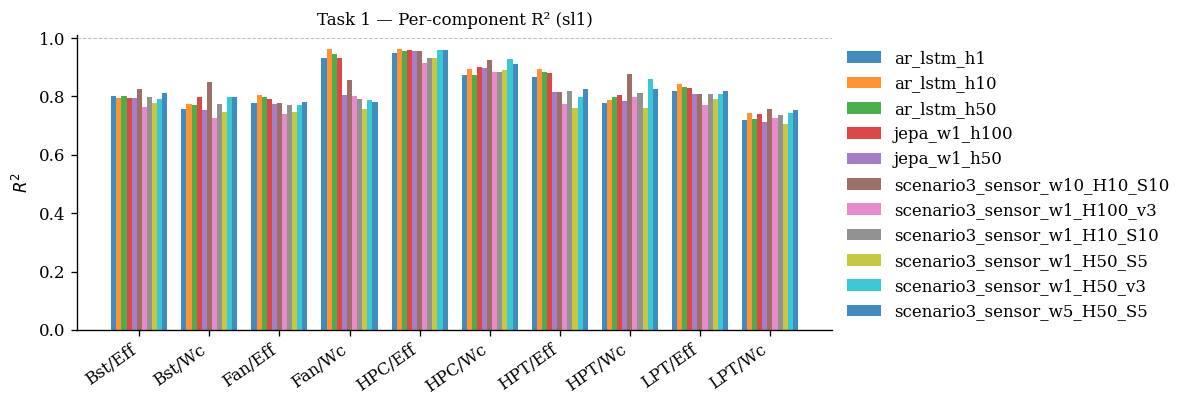

In [11]:
# Per-component R² for a chosen seq_len
SEQ_LEN = "sl1"   # change to "sl10" or "sl50" if available

comp_rows = []
for r in all_results:
    if "error" in r:
        continue
    dims = (r.get("task1_hi") or {}).get(SEQ_LEN, {})
    for comp, metrics in dims.items():
        if comp == "__mean__":
            continue
        comp_rows.append({
            "model": label(r["name"]),
            "component": COMPONENT_SHORT.get(comp, comp),
            "R²": metrics.get("r2", float("nan")),
        })

comp_df = pd.DataFrame(comp_rows)
models  = comp_df["model"].unique()
comps   = list(COMPONENT_SHORT.values())
x = np.arange(len(comps))
width = 0.8 / max(len(models), 1)

fig, ax = plt.subplots(figsize=(10, 3.5))
for i, m in enumerate(sorted(models)):
    sub = comp_df[comp_df["model"] == m].set_index("component")["R²"]
    vals = [float(sub.get(c, np.nan)) for c in comps]
    ax.bar(x + (i - len(models)/2 + 0.5) * width, vals, width, label=m, alpha=0.85)

ax.axhline(1.0, color="grey", lw=0.6, ls="--", alpha=0.5)
ax.set_xticks(x); ax.set_xticklabels(comps, rotation=35, ha="right")
ax.set_ylabel("$R^2$"); ax.set_title(f"Task 1 — Per-component R² ({SEQ_LEN})")
ax.legend(frameon=False, bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.show()


# Task 2 is uniformly broken — showing only R² (all negative, confirming collapse)
t2_rows = []
for r in all_results:
    if "error" in r:
        continue
    for sl_tag, dims in (r.get("task2_delta_hi") or {}).items():
        mean = dims.get("__mean__", {})
        t2_rows.append({
            "model":   label(r["name"]),
            "sl":      sl_tag,
            "R²":      mean.get("r2", float("nan")),
        })

t2_df = pd.DataFrame(t2_rows)
if not t2_df.empty:
    piv = t2_df.pivot(index="model", columns="sl", values="R²").round(4)
    piv["mean R²"] = piv.mean(axis=1).round(4)
    piv = piv.sort_values("mean R²", ascending=False)
    print("⚠️  Task 2 (ΔHI velocity): ALL models fail — probe collapses to constant output.")
    print("    Root cause: ΔHI ≈ 1e-4 per step, indistinguishable from noise.")
    print("    Recommendation: replace with Time-to-Next-Maintenance (TNM) probe.\n")
    display(piv.style
        .background_gradient(cmap="RdYlGn", vmin=-0.05, vmax=0.05)
        .set_caption("Task 2 R² (all values < 0 = worse than predicting the mean)")
        .format("{:.4f}")
        .set_properties(**{"text-align": "center", "font-size": "9pt"})
    )
else:
    print("No Task 2 results.")


In [12]:
t2_rows = []
for r in all_results:
    if "error" in r:
        continue
    for sl_tag, dims in (r.get("task2_delta_hi") or {}).items():
        mean = dims.get("__mean__", {})
        t2_rows.append({
            "model": label(r["name"]),
            "seq_len": sl_tag,
            "R²":        mean.get("r2",        float("nan")),
            "RMSE":      mean.get("rmse",       float("nan")),
            "Pearson-r": mean.get("pearson_r",  float("nan")),
        })

t2_df = pd.DataFrame(t2_rows)
if not t2_df.empty:
    display(t2_df.pivot(index="model", columns="seq_len", values=["R²", "RMSE", "Pearson-r"]).round(4))
else:
    print("No Task 2 results (run with --tasks 1 2 or all)")

R²                 RMSE           Pearson-r  \
seq_len                          sl1    sl10    sl50  sl1 sl10 sl50       sl1   
model                                                                           
ar_lstm_h1                   -0.0123 -0.0134 -0.0043  0.0  0.0  0.0       NaN   
ar_lstm_h10                  -0.0090 -0.0109 -0.0155  0.0  0.0  0.0       NaN   
ar_lstm_h50                  -0.0160 -0.0089 -0.0023  0.0  0.0  0.0       NaN   
jepa_w1_h100                 -0.0210 -0.0097 -0.0098  0.0  0.0  0.0       NaN   
jepa_w1_h50                  -0.0404 -0.0115 -0.0119  0.0  0.0  0.0       NaN   
scenario3_sensor_w10_H10_S10 -0.0065 -0.0044 -0.0073  0.0  0.0  0.0       NaN   
scenario3_sensor_w1_H100_v3  -0.0071 -0.0060 -0.0061  0.0  0.0  0.0       NaN   
scenario3_sensor_w1_H10_S10  -0.0082 -0.0058 -0.0080  0.0  0.0  0.0       NaN   
scenario3_sensor_w1_H50_S5   -0.0105 -0.0075 -0.0073  0.0  0.0  0.0       NaN   
scenario3_sensor_w1_H50_v3   -0.0064 -0.0079 -0.0042  0.0  0.0  0.0       NaN   
scenario3_sensor_w5_H50_S5   -0.0072 -0.0043 -0.0088  0.0  0.0  0.0       NaN   

                                        
seq_len                      sl10 sl50  
model                                   
ar_lstm_h1                    NaN  NaN  
ar_lstm_h10                   NaN  NaN  
ar_lstm_h50                   NaN  NaN  
jepa_w1_h100                  NaN  NaN  
jepa_w1_h50                   NaN  NaN  
scenario3_sensor_w10_H10_S10  NaN  NaN  
scenario3_sensor_w1_H100_v3   NaN  NaN  
scenario3_sensor_w1_H10_S10   NaN  NaN  
scenario3_sensor_w1_H50_S5    NaN  NaN  
scenario3_sensor_w1_H50_v3    NaN  NaN  
scenario3_sensor_w5_H50_S5    NaN  NaN


# Task 2b: AUC = 0.5 everywhere — one-line verdict
alarm_data = {}
for r in all_results:
    if "error" in r:
        continue
    for k_str, metrics in (r.get("task2b_alarm") or {}).items():
        if metrics:
            alarm_data.setdefault(k_str, set()).add(metrics.get("auc"))

if alarm_data:
    print("⚠️  Task 2b (Maintenance Alarm): AUC = 0.5 for ALL models at ALL horizons.")
    print("    Identical to a random classifier. Scores are driven by zero-variance ΔHI predictions.")
    print("    Avg Precision and F1 match the class frequency baseline exactly.")
    for k, aucs in sorted(alarm_data.items()):
        print(f"    {k}: AUC values = {aucs}")
else:
    print("No Task 2b results.")


In [13]:
alarm_rows = []
for r in all_results:
    if "error" in r:
        continue
    for k_str, metrics in (r.get("task2b_alarm") or {}).items():
        if not metrics:
            continue
        alarm_rows.append({
            "model":   label(r["name"]),
            "horizon": k_str,
            "AUC":     metrics.get("auc"),
            "Avg Prec": metrics.get("avg_precision"),
            "F1":      metrics.get("f1"),
        })

alarm_df = pd.DataFrame(alarm_rows)
if not alarm_df.empty:
    display(alarm_df.pivot(index="model", columns="horizon", values=["AUC", "Avg Prec", "F1"]).round(3))
else:
    print("No Task 2b results")

AUC                Avg Prec                      \
horizon                       K10 K100  K20  K50      K10   K100   K20    K50   
model                                                                           
ar_lstm_h1                    0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
ar_lstm_h10                   0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
ar_lstm_h50                   0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
jepa_w1_h100                  0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
jepa_w1_h50                   0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
scenario3_sensor_w10_H10_S10  0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
scenario3_sensor_w1_H100_v3   0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
scenario3_sensor_w1_H10_S10   0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
scenario3_sensor_w1_H50_S5    0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
scenario3_sensor_w1_H50_v3    0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   
scenario3_sensor_w5_H50_S5    0.5  0.5  0.5  0.5    0.025  0.252  0.05  0.126   

                                 F1                       
horizon                         K10   K100    K20    K50  
model                                                     
ar_lstm_h1                    0.049  0.403  0.096  0.224  
ar_lstm_h10                   0.049  0.403  0.096  0.224  
ar_lstm_h50                   0.049  0.403  0.096  0.224  
jepa_w1_h100                  0.049  0.403  0.096  0.224  
jepa_w1_h50                   0.049  0.403  0.096  0.224  
scenario3_sensor_w10_H10_S10  0.049  0.403  0.096  0.224  
scenario3_sensor_w1_H100_v3   0.049  0.403  0.096  0.224  
scenario3_sensor_w1_H10_S10   0.049  0.403  0.096  0.224  
scenario3_sensor_w1_H50_S5    0.049  0.403  0.096  0.224  
scenario3_sensor_w1_H50_v3    0.049  0.403  0.096  0.224  
scenario3_sensor_w5_H50_S5    0.049  0.403  0.096  0.224


t3_results = [
    (label(r["name"]), r["task3_forecast"])
    for r in all_results
    if "error" not in r and r.get("task3_forecast")
]

if not t3_results:
    print("No Task 3 results.")
else:
    all_names  = [n for n, _ in t3_results]
    cmap       = _arch_color_map(all_names)
    # line style: dashed for AR-LSTM so they're distinguishable in B&W too
    def _ls(name): return "--" if name in ARCH_GROUPS.get("AR-LSTM", []) else "-"

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ax_rmse, ax_gap = axes

    for name, t3 in t3_results:
        col = cmap[name]
        ls  = _ls(name)
        tau = np.arange(1, len(t3["mean_rmse_clean"]) + 1)
        ax_rmse.plot(tau, t3["mean_rmse_clean"], color=col, ls=ls, label=name)
        ax_gap.plot(tau,  t3["mean_rmse_gap"],   color=col, ls=ls, label=name)

    # RMSE panel
    ax_rmse.set_yscale("log")
    ax_rmse.set_xlabel(r"Forecast horizon $\tau$ (steps)")
    ax_rmse.set_ylabel("Mean HI RMSE  (log scale)")
    ax_rmse.set_title("Clean-trajectory RMSE(τ)")
    ax_rmse.xaxis.set_minor_locator(mticker.MultipleLocator(5))
    ax_rmse.yaxis.set_major_formatter(mticker.LogFormatterSciNotation(base=10, labelOnlyBase=False))

    # Gap panel
    ax_gap.axhline(0, color="grey", lw=1.0, ls=":", alpha=0.7)
    ax_gap.set_xlabel(r"Forecast horizon $\tau$ (steps)")
    ax_gap.set_ylabel("gap = RMSE(event) − RMSE(clean)")
    ax_gap.set_title("Action-divergence gap(τ)\n"
                     "positive = worse on events  |  negative = better after maintenance")
    ax_gap.xaxis.set_minor_locator(mticker.MultipleLocator(5))

    # Shared legend (deduplicate)
    handles, labels_ = ax_rmse.get_legend_handles_labels()
    # Add architecture patch labels
    from matplotlib.lines import Line2D
    arch_handles = [
        Line2D([0],[0], color="grey", ls="-",  lw=2, label="JEPA"),
        Line2D([0],[0], color="grey", ls="--", lw=2, label="AR-LSTM"),
    ]
    fig.legend(handles + arch_handles,
               labels_ + ["— JEPA", "-- AR-LSTM"],
               loc="lower center", ncol=4,
               bbox_to_anchor=(0.5, -0.18),
               fontsize=8)

    fig.suptitle("Task 3 — Latent Forecasting", fontsize=12, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


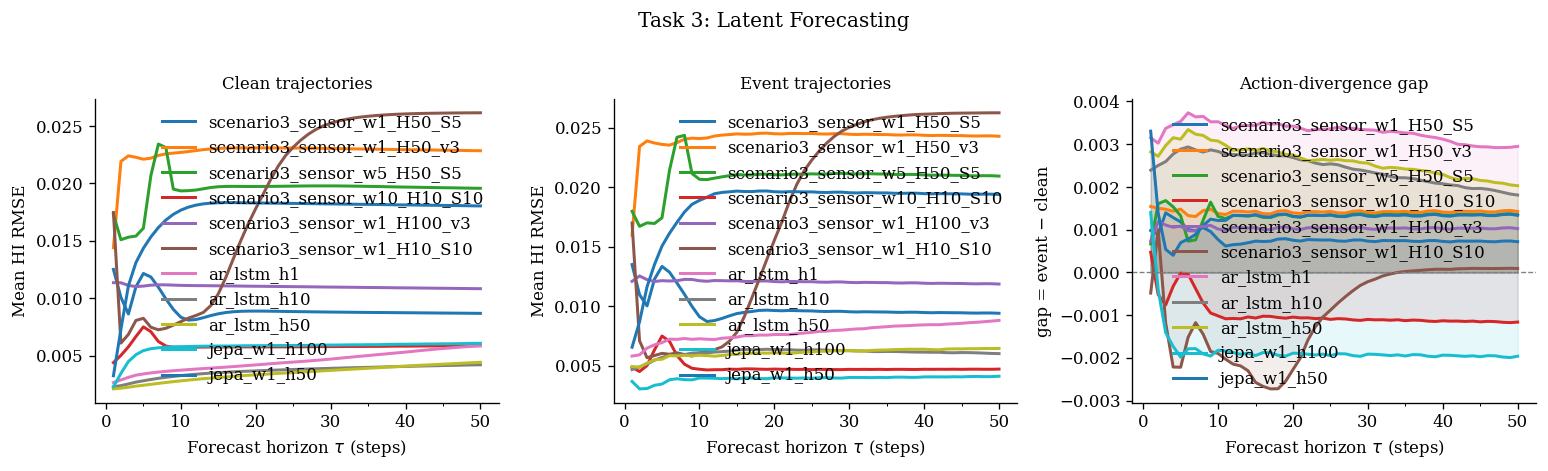

In [14]:
t3_results = [(label(r["name"]), r["task3_forecast"]) for r in all_results
              if "error" not in r and r.get("task3_forecast")]

if not t3_results:
    print("No Task 3 results (run with --tasks 1 2 3 or all)")
else:
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=False)
    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, (name, t3) in enumerate(t3_results):
        col = prop_cycle[i % len(prop_cycle)]
        tau = np.arange(1, len(t3["mean_rmse_all"]) + 1)
        axes[0].plot(tau, t3["mean_rmse_clean"], color=col, label=name)
        axes[1].plot(tau, t3["mean_rmse_event"], color=col, label=name)
        axes[2].plot(tau, t3["mean_rmse_gap"],   color=col, label=name)
        axes[2].fill_between(tau, 0, t3["mean_rmse_gap"], color=col, alpha=0.10)

    axes[2].axhline(0, color="grey", lw=0.8, ls="--")
    for ax, title, ylab in zip(
        axes,
        ["Clean trajectories", "Event trajectories", "Action-divergence gap"],
        ["Mean HI RMSE", "Mean HI RMSE", "gap = event − clean"],
    ):
        ax.set_xlabel(r"Forecast horizon $\tau$ (steps)")
        ax.set_ylabel(ylab); ax.set_title(title)
        ax.legend(frameon=False)
        ax.xaxis.set_minor_locator(mticker.MultipleLocator(5))

    fig.suptitle("Task 3: Latent Forecasting", y=1.02)
    plt.tight_layout(); plt.show()

In [15]:
# Task 3 summary table at key horizons
t3_rows = []
for r in all_results:
    if "error" in r or not r.get("task3_forecast"):
        continue
    t3 = r["task3_forecast"]
    for tau in [1, 5, 10, 20, 50]:
        idx = tau - 1
        if idx >= len(t3.get("mean_rmse_all", [])):
            continue
        t3_rows.append({
            "model": label(r["name"]),
            "τ": tau,
            "RMSE (all)":   t3["mean_rmse_all"][idx],
            "RMSE (clean)": t3["mean_rmse_clean"][idx],
            "RMSE (event)": t3["mean_rmse_event"][idx],
            "gap":          t3["mean_rmse_gap"][idx],
        })

if t3_rows:
    display(pd.DataFrame(t3_rows).set_index(["model", "τ"]).round(5))
else:
    print("No Task 3 results")

RMSE (all)  RMSE (clean)  RMSE (event)  \
model                        τ                                            
scenario3_sensor_w1_H50_S5   1      0.01251       0.01251       0.01349   
                             5      0.01217       0.01215       0.01333   
                             10     0.00836       0.00834       0.00911   
                             20     0.00891       0.00887       0.00963   
                             50     0.00877       0.00868       0.00940   
scenario3_sensor_w1_H50_v3   1      0.01441       0.01440       0.01594   
                             5      0.02213       0.02211       0.02359   
                             10     0.02274       0.02270       0.02408   
                             20     0.02316       0.02309       0.02448   
                             50     0.02303       0.02285       0.02427   
scenario3_sensor_w5_H50_S5   1      0.01730       0.01730       0.01796   
                             5      0.01612       0.01610       0.01742   
                             10     0.01938       0.01934       0.02065   
                             20     0.01980       0.01973       0.02103   
                             50     0.01975       0.01957       0.02092   
scenario3_sensor_w10_H10_S10 1      0.00439       0.00438       0.00485   
                             5      0.00750       0.00750       0.00748   
                             10     0.00569       0.00571       0.00469   
                             20     0.00571       0.00575       0.00471   
                             50     0.00574       0.00587       0.00470   
scenario3_sensor_w1_H100_v3  1      0.01135       0.01135       0.01208   
                             5      0.01107       0.01105       0.01213   
                             10     0.01114       0.01111       0.01213   
                             20     0.01109       0.01104       0.01206   
                             50     0.01096       0.01083       0.01185   
scenario3_sensor_w1_H10_S10  1      0.01746       0.01746       0.01698   
                             5      0.00822       0.00824       0.00603   
                             10     0.00791       0.00795       0.00606   
                             20     0.01770       0.01781       0.01553   
                             50     0.02617       0.02615       0.02624   
ar_lstm_h1                   1      0.00267       0.00265       0.00580   
                             5      0.00348       0.00340       0.00693   
                             10     0.00386       0.00373       0.00725   
                             20     0.00443       0.00418       0.00761   
                             50     0.00631       0.00585       0.00880   
ar_lstm_h10                  1      0.00229       0.00228       0.00467   
                             5      0.00287       0.00280       0.00569   
                             10     0.00336       0.00325       0.00608   
                             20     0.00386       0.00367       0.00636   
                             50     0.00447       0.00419       0.00601   
ar_lstm_h50                  1      0.00212       0.00210       0.00492   
                             5      0.00249       0.00241       0.00553   
                             10     0.00292       0.00279       0.00587   
                             20     0.00352       0.00332       0.00608   
                             50     0.00472       0.00441       0.00644   
jepa_w1_h100                 1      0.00228       0.00227       0.00367   
                             5      0.00541       0.00543       0.00345   
                             10     0.00573       0.00577       0.00395   
                             20     0.00578       0.00586       0.00397   
                             50     0.00585       0.00607       0.00410   
jepa_w1_h50                  1      0.00325       0.00324       0.00654   
                             5      0.01436       0.01435 


# ── Task 1 R² vs probe seq_len ────────────────────────────────────────────────
t1_rows = []
for r in all_results:
    if "error" in r:
        continue
    for sl_tag, dims in (r.get("task1_hi") or {}).items():
        mean = dims.get("__mean__", {})
        t1_rows.append({
            "model":     label(r["name"]),
            "seq_len":   int(sl_tag.replace("sl", "")),
            "R²":        mean.get("r2",       float("nan")),
            "RMSE":      mean.get("rmse",     float("nan")),
            "Pearson-r": mean.get("pearson_r",float("nan")),
        })

t1_df = pd.DataFrame(t1_rows).sort_values("seq_len")

if not t1_df.empty:
    all_models = sorted(t1_df["model"].unique())
    cmap = _arch_color_map(all_models)

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

    for m in all_models:
        sub = t1_df[t1_df["model"] == m].sort_values("seq_len")
        col = cmap[m]
        ls  = "--" if m in ARCH_GROUPS.get("AR-LSTM", []) else "-"
        mk  = "s" if m in ARCH_GROUPS.get("AR-LSTM", []) else "o"
        axes[0].plot(sub["seq_len"], sub["R²"],    color=col, ls=ls, marker=mk, ms=5, label=m)
        axes[1].plot(sub["seq_len"], sub["RMSE"],  color=col, ls=ls, marker=mk, ms=5, label=m)

    axes[0].set_title("Task 1 — R² vs probe seq_len")
    axes[1].set_title("Task 1 — RMSE vs probe seq_len")
    for ax, ylab in zip(axes, ["R²", "RMSE"]):
        ax.set_xlabel("Probe sequence length")
        ax.set_ylabel(ylab)
        ax.set_xticks([1, 10, 50])

    # Legend outside
    handles, labels_ = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", ncol=3,
               bbox_to_anchor=(0.5, -0.22), fontsize=8)

    plt.tight_layout()
    plt.show()

    # Pivot table: R² at each seq_len, sorted by best R²
    piv = t1_df.pivot(index="model", columns="seq_len", values="R²").round(4)
    piv.columns = [f"sl{c}" for c in piv.columns]
    piv["best"] = piv.max(axis=1)
    piv["Δ(sl50−sl1)"] = (piv.get("sl50", float("nan")) - piv.get("sl1", float("nan"))).round(4)
    piv = piv.sort_values("best", ascending=False)
    display(piv.style
        .background_gradient(subset=[c for c in piv.columns if c.startswith("sl")], cmap="YlGn", vmin=0.75, vmax=0.88)
        .background_gradient(subset=["Δ(sl50−sl1)"], cmap="RdYlGn", vmin=-0.05, vmax=0.07)
        .format("{:.4f}")
        .set_caption("Task 1 R² by probe seq_len — Δ>0 means longer context helps")
        .set_properties(**{"text-align": "center", "font-size": "9pt"})
    )


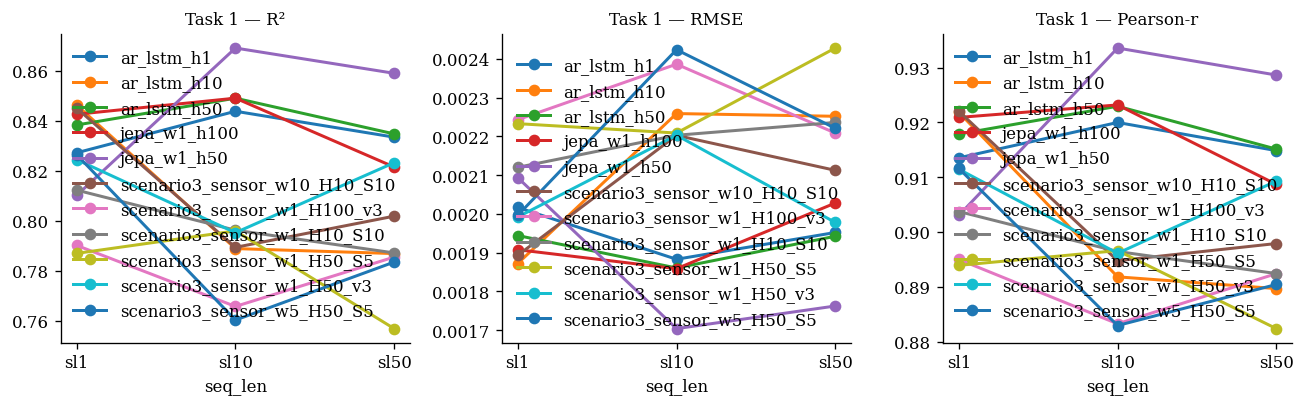

In [16]:
if not t1_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
    prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for metric, ax in zip(["R²", "RMSE", "Pearson-r"], axes):
        for i, m in enumerate(sorted(t1_df["model"].unique())):
            sub = t1_df[t1_df["model"] == m].sort_values("seq_len")
            ax.plot(sub["seq_len"], sub[metric], marker="o",
                    color=prop_cycle[i % len(prop_cycle)], label=m)
        ax.set_title(f"Task 1 — {metric}")
        ax.set_xlabel("seq_len")
        ax.legend(frameon=False)

    plt.tight_layout(); plt.show()